In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
import torchvision.transforms.v2 as v2
from copy import deepcopy
import sys
sys.path.append("/n/home11/sambt/phlab-neurips25/")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

from sklearn.metrics import roc_auc_score, top_k_accuracy_score
#from utils.plotting import make_corner
import os

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# no anomaly in space

In [15]:
f = "/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/histology/results/classifier/classifier_woAnomaly.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

NBKG 1000
NSIG 267


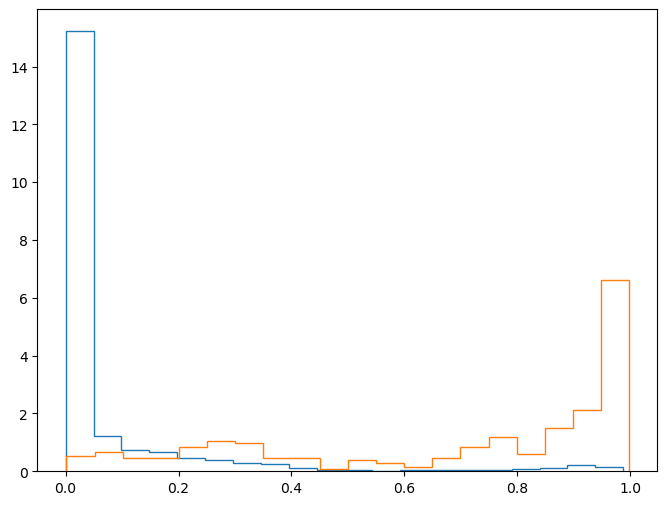

In [16]:
plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

In [22]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.025,0.05,0.1,0.2]
iNBkg = 167
iNRef = 833
Ntoys = 1000
iNBins = 100

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0.1
xmax = 1
plot = False
replace=False
philBin=True
scale_data = 500/iNBkg
#scale_data = 1
for sf in sig_fracs:
    ps = []
    zs = []
    for i in tqdm(range(Ntoys)):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=replace)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=replace)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=xmin,xmax=xmax,plot=plot,philBin=philBin,scale_data=scale_data)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

100%|██████████| 1000/1000 [00:06<00:00, 152.80it/s]


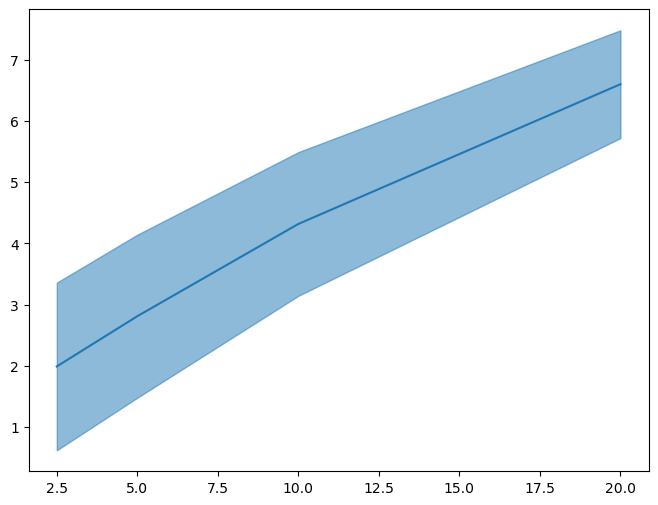

In [23]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [25]:
np.savez("histology_idealZscores_vanillaSpace",zscores=zscores,fracs=sig_fracs)

# with anomaly in space

In [26]:
f = "/n/holystore01/LABS/iaifi_lab/Lab/phlab-neurips25/histology/results/classifier/classifier_wAnomaly.npz"
x = np.load(f)
labels = x['label']
bkg_test_preds = x['predict'][labels==0]
sig_test_preds = x['predict'][labels==1]
print("NBKG",len(bkg_test_preds))
print("NSIG",len(sig_test_preds))

NBKG 687
NSIG 218


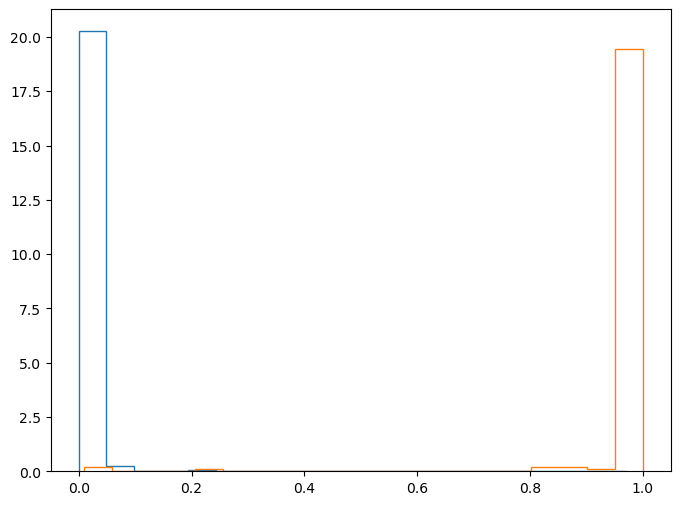

In [27]:
plt.figure(figsize=(8,6))
#bins = np.linspace(0,1,20)
bins = 20
h1 = plt.hist(bkg_test_preds,bins=bins,density=True,histtype='step')
h1 = plt.hist(sig_test_preds,bins=bins,density=True,histtype='step')

In [28]:
from scipy.stats import chi2, norm
from utils.fitting import dLL

sig_fracs = [0.025,0.05,0.1,0.2]
iNBkg = 115
iNRef = 572
Ntoys = 1000
iNBins = 100

pvalues = []
psigmas = []
zscores = []
zsigmas = []
xmin = 0.1
xmax = 1
plot = False
replace=False
philBin=True
scale_data = 500/iNBkg
#scale_data = 1
for sf in sig_fracs:
    ps = []
    zs = []
    for i in tqdm(range(Ntoys)):
        ref_bkg = np.random.choice(bkg_test_preds,size=iNBkg+iNRef,replace=replace)
        iRef = ref_bkg[:iNRef]
        iBkg = ref_bkg[iNRef:iNRef+iNBkg]
        iNSig = int(sf*iNBkg)
        iSig = np.random.choice(sig_test_preds,size=iNSig,replace=replace)
        iData = np.concatenate([iBkg,iSig])
        #print(iSig.shape)
        #print(iBkg.shape)
        #print(iRef.shape)
        
        t = dLL(iData,iRef,sig_test_preds,iNSig,iNBkg,iNBins=iNBins,xmin=xmin,xmax=xmax,plot=plot,philBin=philBin,scale_data=scale_data)
        p = chi2.cdf(t, 1)
        z = norm.ppf(p)
        if np.isfinite(z) and not np.isnan(z):
            ps.append(p)
            zs.append(z)
    pvalues.append(np.mean(ps))
    psigmas.append(np.std(ps))
    zscores.append(np.mean(zs))
    zsigmas.append(np.std(zs))
pvalues = np.array(pvalues)
psigmas = np.array(psigmas)
zscores = np.array(zscores)
zsigmas = np.array(zsigmas)

100%|██████████| 1000/1000 [00:06<00:00, 152.55it/s]


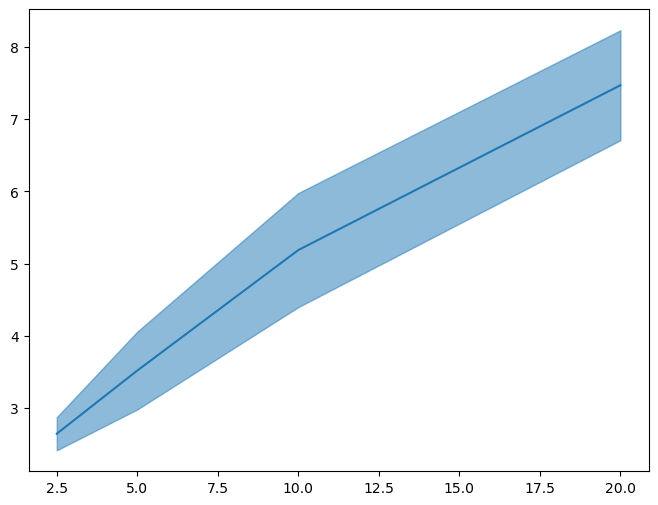

In [29]:
plt.figure(figsize=(8,6))
plt.plot(100*np.array(sig_fracs),zscores)
plt.fill_between(100*np.array(sig_fracs),zscores-zsigmas,zscores+zsigmas,color='C0',alpha=0.5)

In [30]:
np.savez("histology_idealZscores_SpaceWithAnom.npz",zscores=zscores,fracs=sig_fracs)